In [139]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [ ]:
Ro = -1
Co = 0
N_cheb = 99
R = 285.36
be = 0.07759
Mr = 0.1
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
num = 2
Ma = Mr/R
c = 0.35
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
# H,T = T_ca(Mr,f,q,w0,gamma,Tw)
# F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
# lam = - (2/3) * T
# kappa = (1/sigma) * T
# A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
# nep = PEP([A0,A1,A2]); 
# eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)

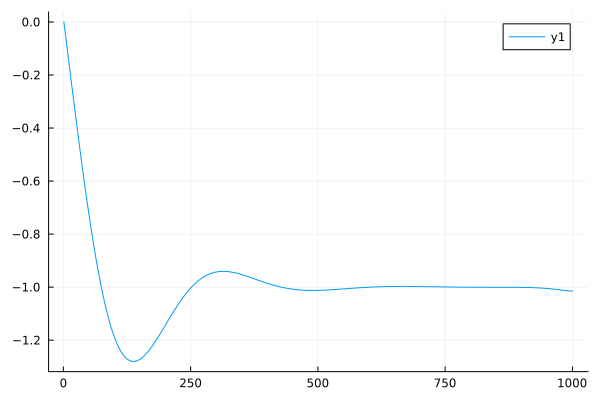

In [138]:
plot(v0)

In [ ]:
N_cheb = 99
Mr = 0.2
Tw = 0.9
gamma = 1.4
sigma = 0.72
omega = 0.008
R0 = 320
R0_step = 1
R1 = 320
be0 = 0.14
be1 = 0
be_step = - 0.001
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [0 0 0]
@showprogress for R = R0 : R0_step : R1
    if R < 400

        c = 0.5

    else 

        c = 0.6

    end

    Ma = Mr/R
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num :: Int64 = 2
    for be = be0 : be_step : be1
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
        if netural_cur_imag[end,3] == 0
         
            point = filter(x ->  - 0.001 < imag(x) < 0.001 && real(x)>0.01, eigval)
        
        else 

            point = eigval[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]),eigval)[2]]
        
        end

        if point == []

            eig = -1
           
            if 0.04 < be < 0.14

                c = 0.5

            else

                c = 0.2

            end
        
            num = 1

        else        
            eig = point[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]), point)[2]]
            c = eig
            num = 2
        end
        netural_cur = [netural_cur; [R be eig]]
        netural_cur_real = [netural_cur_real; [R be real(eig)]]
        netural_cur_imag = [netural_cur_imag; [R be imag(eig)]]
    end
        netural_cur = [netural_cur; [-1 -1 -1]]
        netural_cur_real = [netural_cur_real; [-1 -1 -1]]
        netural_cur_imag = [netural_cur_imag; [0 0 0]] 
end
netural_cur_imag_filter1 = netural_cur_imag
for i  = 2 : 1 : length(netural_cur_imag_filter1[:,1])-1
    if netural_cur_imag_filter1[i - 1 ,3] == 0 && netural_cur_imag_filter1[i + 1,3] > 0
        netural_cur_imag_filter1[i,3] = abs(netural_cur_imag_filter1[i,3])
    end
end
netural_cur_imag_filter = filter(row -> row[1] != 0, eachrow(netural_cur_imag_filter1))
writedlm("test_neturalcur_imag_0.008_0.9_2_.dat",netural_cur_imag_filter)
writedlm("test_neturalcur_real_0.008_0.9_2_.dat",netural_cur_real)
writedlm("test_neturalcur_0.008_0.9_2_.dat",netural_cur)

In [66]:
data1 = readdlm("test_neturalcur_imag_0.8_3.dat")
data2 = readdlm("test_neturalcur_imag_0.8_3_temp.dat")

713×3 Matrix{Float64}:
 440.0  0.04    0.0
 440.0  0.041   0.0
 440.0  0.042   0.0
 440.0  0.043   0.0
 440.0  0.044   0.0
 440.0  0.045   0.0
 440.0  0.046   0.0
 440.0  0.047   0.00475119
 440.0  0.048   0.00422465
 440.0  0.049   0.00371843
   ⋮           
 470.0  0.054  -0.000741783
 470.0  0.055  -0.00114032
 470.0  0.056  -0.00141622
 470.0  0.057  -0.00164443
 470.0  0.058  -0.00168567
 470.0  0.059  -0.001485
 470.0  0.06   -0.00104786
 470.0  0.061  -0.000136485
 470.0  0.062   0.00185655

In [67]:
for i = 1 : 1 : length(data2[:,1])
    
    for j = 1 : 1 : length(data1[:,1])
        
        if data2[i,1] == data1[j,1] && data2[i,2] == data1[j,2] && data2[i,3] * data1[j,3] < 0
            
            data1[j,3] = data2[i,3]
            
        end
    end
    
end

In [68]:
writedlm("neturalcur_imag_0.8_3.dat",data1)

In [64]:
N_cheb = 99
Mr = 0.3
Tw = 1.2
gamma = 1.4
sigma = 0.72
omega = 0
R0 = 260
step = 1
R1 = 500
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [0 0 0]
@showprogress for R = R0 : step : R1
    if R < 400

        c = 0.5

    else 
        c = 0.6
    end

    Ma = Mr/R
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num :: Int64 = 2
     for be = 0.16 : -0.001 : 0.02
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
        if netural_cur_imag[end,3] == 0
            point = filter(x ->  - 0.001 < imag(x) < 0.005 && real(x)>0.05, eigval)
        else 
            point = eigval[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]),eigval)[2]]
        end

        if point == []

            eig = -1
           
            if R <= 400

                c = 0.5

            elseif R > 400 && 0.05 < be < 0.16

                c = 0.6
            else

                c = 0.15
            end
            
            num = 2
        else        
            eig = point[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]), point)[2]]
            c = eig
            num = 1
        end
        netural_cur = [netural_cur; [R be eig]]
        netural_cur_real = [netural_cur_real; [R be real(eig)]]
        netural_cur_imag = [netural_cur_imag; [R be imag(eig)]]
    end
        netural_cur = [netural_cur; [-1 -1 -1]]
        netural_cur_real = [netural_cur_real; [-1 -1 -1]]
        netural_cur_imag = [netural_cur_imag; [0 0 0]]
end
netural_cur_imag_filter1 = netural_cur_imag
for i  = 2 : 1 : length(netural_cur_imag_filter1[:,1])-1
    if netural_cur_imag_filter1[i - 1 ,3] == 0 && netural_cur_imag_filter1[i + 1,3] > 0
        netural_cur_imag_filter1[i,3] = abs(netural_cur_imag_filter1[i,3])
    end
end
netural_cur_imag_filter = filter(row -> row[1] != 0, eachrow(netural_cur_imag_filter1))
writedlm("test_neturalcur_imag_1.2_3.dat",netural_cur_imag_filter)
writedlm("test_neturalcur_real_1.2_3.dat",netural_cur_real)
writedlm("test_neturalcur_1.2_3.dat",netural_cur)

Progress: 100%|█████████████████████████████████████████| Time: 2:56:16
